# <center>**EXPERIMENT 1  - MACHINE LEARNING FOR CALCIFIC TENDINOPATHY** </center>

# Machine Learning for Calcifying Tendinopathy  
### Table of Contents

1. **Notebook Overview**  
   - Objective of the hybrid CNN + classical ML approach  
   - Use of CNN-extracted deep features instead of raw images  
   - Role of this notebook within Experiment 1 (comparison with the end-to-end CNN model)  

2. **Environment Setup**  
   - Import of required libraries  
   - Random seed configuration for reproducibility  
   - Plotting style and basic warning control  

3. **Data Loading and Initial Preparation**  
   - Load pre-computed CNN feature tables for train/test sets  
   - Basic integrity checks (shapes, label distribution, feature consistency)  
   - Cleaning of non-ML metadata columns and missing-value handling  
   - Definition of `X_train`, `X_test`, `y_train`, `y_test`  

4. **Correlation-Based Feature Filtering and Random Forest Ranking**  
   - Removal of highly correlated features to reduce redundancy  
   - Feature importance estimation using Random Forest  
   - Automatic selection of the optimal number of features (*k*) via cross-validation  
   - Construction of the final preprocessing pipeline for Route 1  

5. **PCA-Based Dimensionality Reduction**  
   - Preparation of numeric and categorical feature space for PCA  
   - PCA fitting using a variance-retention criterion  
   - Transformation of train and test sets into PCA space  

6. **Comparison of Dimensionality Reduction Strategies**  
   - Training of baseline classifiers for Route 1 (RF-selected features) and Route 2 (PCA)  
   - Test-set performance comparison to guide method selection  

7. **Final Dataset Selection**  
   - Rule-based decision between Route 1 and Route 2  
   - Final definition of `X_train_sel` and `X_test_sel`  

8. **Training and Hyperparameter Optimisation of Classical ML Models**  
   - Models: logistic regression, k-nearest neighbours, SVM, decision tree, random forest  
   - Stratified cross-validation using ROC AUC as the primary metric  
   - Grid search, training time analysis, and model persistence  

9. **Comparative Evaluation on the Test Set**  
   - Test-set metrics: sensitivity, specificity, PPV, NPV, F1-score, accuracy, ROC AUC  
   - Summary table of results and identification of the best-performing model  

10. **Feature Importance Analysis**  
    - Model-specific importance measures (tree-based importances or linear coefficients)  
    - Visualisation of the most relevant CNN-derived features  

11. **Model Interpretability with SHAP**  
    - SHAP-based explanations for the selected best classical ML model  
    - Global SHAP summary plot (beeswarm) and interpretation  

12. **Summary and Conclusions**  
    - Overall performance of classical ML models trained on CNN-extracted features  
    - Key insights from dimensionality reduction and model comparison  
    - Implications for using CNNs as feature extractors in medical imaging  


### **1. Notebook Overview**

In this notebook we train and optimise a set of classical machine learning (ML) classifiers using image features extracted from the best convolutional neural network (CNN) of Experiment 1. The goal is to build a hybrid pipeline in which the CNN acts as a fixed feature extractor and a conventional ML model performs the final binary classification (presence vs absence of rotator cuff calcifications).

The workflow implemented in this notebook includes:

- Loading pre-computed CNN feature vectors for the training and test sets, together with their ground-truth labels.  
- Optional preprocessing of the feature space (standardisation, dimensionality reduction and/or feature selection).  
- Definition and hyperparameter tuning of several ML models (logistic regression, k-nearest neighbours, support vector machine, decision tree and random forest) using stratified cross-validation with ROC AUC as the primary metric.  
- Comparison of cross-validated performance across models, selection of the best-performing classifier and saving of the tuned models and summary tables to disk.

The external evaluation of the selected hybrid model and its direct comparison with the end-to-end CNN (ROC curves, statistical tests such as DeLong, etc.) are performed in a separate notebook, in order to keep this document focused on model training and optimisation.


### **2. Environment Setup**

In [8]:
# Standard library
import os
import json
import time
import warnings
from datetime import datetime

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

# Scikit-learn: model selection & preprocessing
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Scikit-learn: models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score


# Scikit-learn: evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from statsmodels.stats.contingency_tables import mcnemar


# Scikit-learn: warnings
from sklearn.exceptions import ConvergenceWarning

# Global random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style (consistent across notebooks)
sns.set(style="whitegrid")

# Silence convergence warnings during hyperparameter search
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)


### **3. Data Loading and Initial Preparation**

In [3]:
# Paths to deep feature tables exported from the CNN pipeline
train_features_path = "EXP1_ML_train_features_only_embeddings.csv"
test_features_path  = "EXP1_ML_test_features_only_embeddings.csv"

# Load train and test feature sets
df_train = pd.read_csv(train_features_path)
df_test  = pd.read_csv(test_features_path)

print(f"Train feature table shape: {df_train.shape}")
print(f"Test feature table shape:  {df_test.shape}")

# Optional: label distribution check
if "label" in df_train.columns:
    print("\nLabel distribution – TRAIN:")
    print(df_train["label"].value_counts())

if "label" in df_test.columns:
    print("\nLabel distribution – TEST:")
    print(df_test["label"].value_counts())

# Sanity check: number of deep features
feature_cols = [c for c in df_train.columns if c.startswith("feature_")]
print(f"\nNumber of deep features: {len(feature_cols)}")


def clean_ml_dataframe(df, name="dataset"):
    """
    Clean the feature tables used for Machine Learning models.
    Removes metadata columns not used by ML classifiers and
    applies a consistent missing-value strategy.
    """
    df = df.copy()

    # Columns not used by ML models
    cols_to_drop = [
        "date_rx",
        "birthdate",
        "station_name",
        "vector_norm",
        "sex",
        "rx_cod",
        "Unnamed: 0"
    ]
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors="ignore")

    # Ensure label is integer
    if "label" in df.columns:
        df["label"] = df["label"].astype(int)

    # Handle missing values
    missing = df.isnull().sum().sum()
    if missing > 0:
        print(f"[{name}] Missing values before imputation: {missing}")
        df = df.fillna(0)

    print(f"[{name}] Final shape after cleaning: {df.shape}")
    return df


# Clean train and test tables
df_train_clean = clean_ml_dataframe(df_train, name="TRAIN")
df_test_clean  = clean_ml_dataframe(df_test,  name="TEST")

# Separate features and labels
X_train = df_train_clean.drop(columns=["label"])
y_train = df_train_clean["label"]

X_test  = df_test_clean.drop(columns=["label"])
y_test  = df_test_clean["label"]

print("\nFinal ML matrices:")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape} | y_test:  {y_test.shape}")


Train feature table shape: (4268, 514)
Test feature table shape:  (480, 514)

Label distribution – TRAIN:
label
1    2134
0    2134
Name: count, dtype: int64

Label distribution – TEST:
label
0    240
1    240
Name: count, dtype: int64

Number of deep features: 512
[TRAIN] Final shape after cleaning: (4268, 513)
[TEST] Final shape after cleaning: (480, 513)

Final ML matrices:
X_train: (4268, 512) | y_train: (4268,)
X_test:  (480, 512) | y_test:  (480,)


### **4. Correlation-based filtering + Random Forest ranking + Automatic selection of optimal number of features (k)**

❗️ Non-numeric columns removed before Random Forest: []


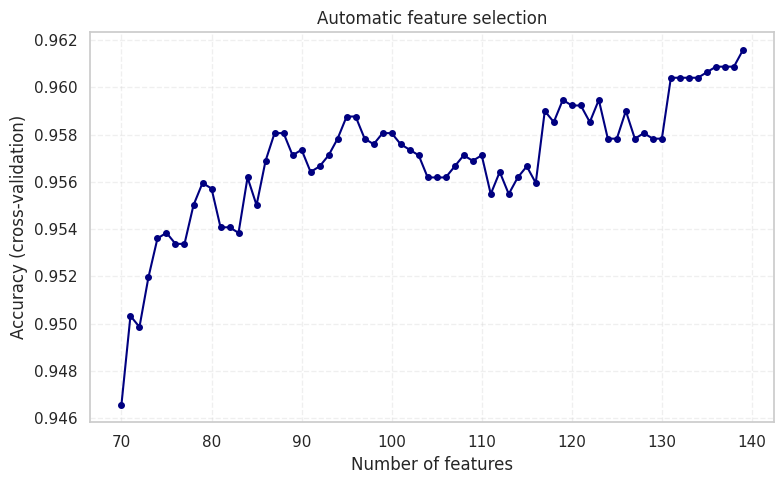

Best number of features: 139, Accuracy: 0.9616


['final_features.pkl']

In [4]:
# 1. Remove highly correlated features
def remove_correlated_features(df, threshold=0.9, exclude_cols=None):
    if exclude_cols is None:
        exclude_cols = []

    # Keep only numeric columns
    numeric_df = df.select_dtypes(include=[np.number])

    # Drop excluded columns if present
    numeric_df = numeric_df.drop(columns=exclude_cols, errors="ignore")

    # Absolute correlation matrix
    corr_matrix = numeric_df.corr().abs()

    # Upper triangle of the correlation matrix
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    # Identify columns to drop
    to_drop = [
        column for column in upper.columns
        if any(upper[column] > threshold)
    ]

    return df.drop(columns=to_drop, errors="ignore"), to_drop


# 1.1 Apply correlation-based filtering
X_corr_filtered, _ = remove_correlated_features(X_train)

# 1.2 Remove any remaining non-numeric columns
non_numeric_cols = X_corr_filtered.select_dtypes(exclude=[np.number]).columns
print("❗️ Non-numeric columns removed before Random Forest:", list(non_numeric_cols))
X_corr_filtered = X_corr_filtered.drop(columns=non_numeric_cols)


# 2. Random Forest to estimate feature importance
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

X_rf = X_corr_filtered.copy()

rf.fit(X_rf, y_train)

feature_importances = pd.Series(
    rf.feature_importances_,
    index=X_rf.columns
).sort_values(ascending=False)


# 3. Evaluate different numbers of top-ranked features
k_list = list(range(70, min(140, len(feature_importances) + 1)))
scores = []

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for k in k_list:
    selected_features = feature_importances.head(k).index.tolist()

    X_train_k = X_train[selected_features]

    # Identify categorical and numeric columns
    categorical_cols = X_train_k.select_dtypes(exclude=[np.number]).columns.tolist()
    numeric_cols = X_train_k.select_dtypes(include=[np.number]).columns.tolist()

    # Preprocessing + classifier pipeline
    preprocessor = ColumnTransformer([
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
    ])

    model = Pipeline([
        ("preproc", preprocessor),
        ("clf", LogisticRegression(max_iter=1000, random_state=42)),
    ])

    score = cross_val_score(
        model,
        X_train_k,
        y_train,
        cv=cv,
        scoring="accuracy"
    ).mean()

    scores.append(score)


# 4. Plot cross-validated performance as a function of k
plt.figure(figsize=(8, 5))
plt.plot(k_list, scores, marker="o", markersize=4, color="navy")
plt.xlabel("Number of features")
plt.ylabel("Accuracy (cross-validation)")
plt.title("Automatic feature selection")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()

plt.savefig("feature_selection_accuracy.png", dpi=300)
plt.show()


# 5. Select the optimal number of features
best_k = k_list[np.argmax(scores)]
print(f"Best number of features: {best_k}, Accuracy: {max(scores):.4f}")


# 6. Apply final feature selection
top_features_rf = feature_importances.head(best_k).index.tolist()
final_features = top_features_rf.copy()

X_train_sel = X_train[final_features]
X_test_sel  = X_test[final_features]


# 7. Define final categorical and numeric columns
categorical_cols = X_train_sel.select_dtypes(exclude=[np.number]).columns.tolist()
numeric_cols = X_train_sel.select_dtypes(include=[np.number]).columns.tolist()


# 8. Final preprocessing transformer (reusable downstream)
preprocessor_1 = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
])

joblib.dump(final_features, "final_features.pkl")

### **5. PCA-based dimensionality reduction**

In [5]:
# 1. Keep only numeric columns
X_train_clean = X_train.select_dtypes(include=[np.number]).copy()
X_test_clean  = X_test.select_dtypes(include=[np.number]).copy()

# 2. Identify categorical columns that should be preserved
categorical_cols_all = []

# 3. Add categorical columns back to the cleaned datasets
for col in categorical_cols_all:
    X_train_clean[col] = X_train[col]
    X_test_clean[col]  = X_test[col]

# 4. Define numeric columns (everything except categoricals)
numeric_cols_all = [c for c in X_train_clean.columns if c not in categorical_cols_all]

# 5. Full preprocessing: scaling for numeric
preprocessor_2 = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols_all),
])

# 6. Apply preprocessing
X_train_processed = preprocessor_2.fit_transform(X_train_clean)
X_test_processed  = preprocessor_2.transform(X_test_clean)

# 7. Apply PCA (retain 95% cumulative explained variance)
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca  = pca.transform(X_test_processed)

# 8. Report PCA summary
print(f"[PCA] Number of retained components: {pca.n_components_}")
print(f"[PCA] Cumulative explained variance: {np.sum(pca.explained_variance_ratio_):.4f}")

[PCA] Number of retained components: 362
[PCA] Cumulative explained variance: 0.9502


### **6. Choice of dimensionality reduction strategy**

In [6]:
# Train and evaluate model – Path 1 (Random Forest feature selection)

pipeline_1 = Pipeline(steps=[
    ("preprocessor", preprocessor_1),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])

pipeline_1.fit(X_train_sel, y_train)

y_pred_1 = pipeline_1.predict(X_test_sel)
y_prob_1 = pipeline_1.predict_proba(X_test_sel)[:, 1]


# Train and evaluate model – Path 2 (PCA-based dimensionality reduction)

clf_pca = LogisticRegression(max_iter=1000, random_state=42)
clf_pca.fit(X_train_pca, y_train)

y_pred_2 = clf_pca.predict(X_test_pca)
y_prob_2 = clf_pca.predict_proba(X_test_pca)[:, 1]


# Evaluation metrics

def evaluate_model(y_true, y_pred, y_prob, name=""):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)

    print(f"\n=== {name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC AUC:   {auc:.4f}")

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": auc,
        "conf_matrix": confusion_matrix(y_true, y_pred),
    }

# Results

results_models = {}

results_models["Path 1 - RF Feature Selection"] = evaluate_model(
    y_test,
    y_pred_1,
    y_prob_1,
    name="Path 1 - RF Feature Selection",
)

results_models["Path 2 - PCA"] = evaluate_model(
    y_test,
    y_pred_2,
    y_prob_2,
    name="Path 2 - PCA",
)


=== Path 1 - RF Feature Selection ===
Accuracy:  0.8875
Precision: 0.8661
Recall:    0.9167
F1-Score:  0.8907
ROC AUC:   0.9605

=== Path 2 - PCA ===
Accuracy:  0.8417
Precision: 0.8228
Recall:    0.8708
F1-Score:  0.8462
ROC AUC:   0.9293


### **7. Final dataset selection**

In [7]:
print("\n=== FINAL DECISION ===")

res_path1 = results_models["Path 1 - RF Feature Selection"]
res_path2 = results_models["Path 2 - PCA"]

if pca.n_components_ > 70:
    print(f"Path 1 is preferable: PCA generated {pca.n_components_} components (>70)")
    final_method = "Path 1"

elif res_path2["f1"] >= res_path1["f1"]:
    print(
        f"Path 2 is preferable: PCA generated {pca.n_components_} components with better or equal F1-score"
    )
    final_method = "Path 2"

else:
    print(
        f"Path 1 is preferable: Better F1-score even though PCA generated fewer than 70 components"
    )
    final_method = "Path 1"

print(f"\n>>> Selected method: {final_method}")

# If the PCA-based path is selected, overwrite the final train/test matrices
if final_method != "Path 1":
    X_train_sel, X_test_sel = X_train_pca, X_test_pca


=== FINAL DECISION ===
Path 1 is preferable: PCA generated 362 components (>70)

>>> Selected method: Path 1


### **8. Training and tuning classic ML models**

In [9]:
# Cross-validation strategy (fixed seed for reproducibility)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Model definitions and hyperparameter grids
model_params = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000),
        "params": {
            "C": [0.001, 0.01, 0.1, 1, 10, 100],
            "penalty": ["l1", "l2"],
            "solver": ["liblinear", "saga"],
        },
    },
    "K-Nearest Neighbors": {
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": list(range(1, 21)),
            "weights": ["uniform", "distance"],
            "p": [1, 2],
        },
    },
    "Support Vector Machine": {
        "model": SVC(probability=True),
        "params": {
            "C": [0.01, 0.1, 1, 10, 100],
            "kernel": ["linear", "rbf", "sigmoid", "poly"],
            "gamma": ["scale", "auto"],
        },
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(),
        "params": {
            "max_depth": [None, 5, 10, 20, 30],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4, 6],
            "criterion": ["gini", "entropy"],
            "max_features": [None, "sqrt", "log2"],
        },
    },
    "Random Forest": {
        "model": RandomForestClassifier(),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [None, 10, 20, 30],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ["sqrt", "log2", None],
            "bootstrap": [True, False],
        },
    },
}

# Output directory (kept for reproducibility / optional reuse)
os.makedirs("classic_models", exist_ok=True)

trained_models = {}
best_scores = {}
best_estimators = {}
results_rows = []

print(f"\n🧪 Using X_train_sel with shape: {X_train_sel.shape}")

for name, mp in model_params.items():
    print(f"\n🔍 Training and tuning {name}...")

    # Pipeline with the classifier only (preprocessing was applied upstream)
    pipeline = Pipeline(steps=[
        ("classifier", mp["model"])
    ])

    # GridSearchCV parameter names must match pipeline step prefix
    param_grid = {f"classifier__{k}": v for k, v in mp["params"].items()}

    start = time.time()
    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=skf,
        scoring="roc_auc",
        n_jobs=-1
    )
    grid.fit(X_train_sel, y_train)
    duration = round(time.time() - start, 2)

    # Store best estimators and CV scores
    best_estimators[name] = grid.best_estimator_
    trained_models[name] = grid.best_estimator_
    best_scores[name] = grid.best_score_

    # Prints intentionally kept identical (including emojis)
    print(f"Best parameters: {grid.best_params_}")
    print(f"Best AUC (CV): {grid.best_score_:.4f}")
    print(f"⏱️  Training time: {duration} seconds")

    # Append to summary table
    results_rows.append({
        "model": name,
        "best_cv_auc": round(grid.best_score_, 4),
        "best_params": json.dumps(grid.best_params_),
        "time_seconds": duration,
    })

    # Persist best estimator (timestamped)
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    filename = f"classic_models/{name.replace(' ', '_')}_{timestamp}.pkl"
    joblib.dump(grid.best_estimator_, filename)

# Save global results table
df_results = pd.DataFrame(results_rows)
csv_timestamp = time.strftime("%Y%m%d_%H%M%S")
csv_name = f"classic_ML_models_validation_results_{csv_timestamp}.csv"
df_results.to_csv(csv_name, index=False)

print(f"\n📄 Results saved to: {csv_name}")


🧪 Using X_train_sel with shape: (4268, 139)

🔍 Training and tuning Logistic Regression...
Best parameters: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}
Best AUC (CV): 0.9912
⏱️  Training time: 44.63 seconds

🔍 Training and tuning K-Nearest Neighbors...
Best parameters: {'classifier__n_neighbors': 19, 'classifier__p': 2, 'classifier__weights': 'uniform'}
Best AUC (CV): 0.9824
⏱️  Training time: 9.86 seconds

🔍 Training and tuning Support Vector Machine...
Best parameters: {'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Best AUC (CV): 0.9911
⏱️  Training time: 1038.89 seconds

🔍 Training and tuning Decision Tree...
Best parameters: {'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__max_features': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10}
Best AUC (CV): 0.9057
⏱️  Training time: 35.82 seconds

🔍 Training and tuning Random Forest...
Best parameters: {'classi

### **9. Comparative metrics table (all models) + export + TOP-3 by AUC**

In [16]:
output_dir = "classic_models"
os.makedirs(output_dir, exist_ok=True)

timestamp = time.strftime("%Y%m%d_%H%M%S")
csv_final_metrics = os.path.join(output_dir, f"classic_ML_full_metrics_{timestamp}.csv")

metrics_rows = []
pred_store = {}
proba_store = {}

for name, model in trained_models.items():
    try:
        y_pred = model.predict(X_test_sel)

        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test_sel)[:, 1]
        elif hasattr(model, "decision_function"):
            y_proba = model.decision_function(X_test_sel)
            y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min())
        else:
            y_proba = None

        pred_store[name] = y_pred
        proba_store[name] = y_proba

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        recall = recall_score(y_test, y_pred, zero_division=0)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        precision = precision_score(y_test, y_pred, zero_division=0)
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0
        f1 = f1_score(y_test, y_pred, zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

        metrics_rows.append({
            "model": name,
            "cut_off": 0.5,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
            "sensitivity": round(recall, 3),
            "specificity": round(specificity, 3),
            "ppv": round(precision, 3),
            "npv": round(npv, 3),
            "accuracy": round(accuracy, 3),
            "f1": round(f1, 3),
            "auc": round(auc, 3) if auc is not None else None,
        })

    except Exception as e:
        print(f"[{name}] Evaluation error: {e}")

df_metrics = pd.DataFrame(metrics_rows)
df_metrics.to_csv(csv_final_metrics, index=False)

top_3_models = df_metrics.sort_values(by="auc", ascending=False).head(3)

print("\n=== TOP 3 MODELS BY AUC ===")
print(top_3_models.to_string(index=False))
print(f"\nMetrics saved to: {csv_final_metrics}")


=== TOP 3 MODELS BY AUC ===
                 model  cut_off  tn  fp  fn  tp  sensitivity  specificity   ppv   npv  accuracy    f1   auc
   Logistic Regression      0.5 212  28  26 214        0.892        0.883 0.884 0.891     0.887 0.888 0.961
Support Vector Machine      0.5 211  29  26 214        0.892        0.879 0.881 0.890     0.885 0.886 0.961
   K-Nearest Neighbors      0.5 226  14  40 200        0.833        0.942 0.935 0.850     0.887 0.881 0.955

Metrics saved to: classic_models/classic_ML_full_metrics_20260413_213445.csv


In [21]:
model_1 = "Logistic Regression"
model_2 = "Support Vector Machine"

pred_1 = pred_store[model_1]
pred_2 = pred_store[model_2]

correct_1 = pred_1 == y_test
correct_2 = pred_2 == y_test

b = np.sum((correct_1 == True) & (correct_2 == False))   # model 1 correct, model 2 wrong
c = np.sum((correct_1 == False) & (correct_2 == True))   # model 1 wrong, model 2 correct

table = [[0, b],
         [c, 0]]

result = mcnemar(table, exact=True)

print(f"\n=== McNemar test: {model_1} vs {model_2} ===")
print(f"Discordant pairs: b={b}, c={c}")
print(f"p-value: {result.pvalue:.4f}")

if result.pvalue < 0.05:
    print("There is a statistically significant difference in classification performance.")
else:
    print("No statistically significant difference was detected in classification performance.")



=== McNemar test: Logistic Regression vs Support Vector Machine ===
Discordant pairs: b=5, c=4
p-value: 1.0000
No statistically significant difference was detected in classification performance.


In [22]:
def bootstrap_auc_difference(y_true, scores_1, scores_2, n_bootstrap=2000, random_state=42):
    rng = np.random.RandomState(random_state)
    y_true = np.asarray(y_true)
    scores_1 = np.asarray(scores_1)
    scores_2 = np.asarray(scores_2)

    auc_diffs = []

    for _ in range(n_bootstrap):
        idx = rng.randint(0, len(y_true), len(y_true))

        # Need both classes in the resample
        if len(np.unique(y_true[idx])) < 2:
            continue

        auc_1 = roc_auc_score(y_true[idx], scores_1[idx])
        auc_2 = roc_auc_score(y_true[idx], scores_2[idx])
        auc_diffs.append(auc_1 - auc_2)

    auc_diffs = np.array(auc_diffs)
    diff_mean = auc_diffs.mean()
    ci_low, ci_high = np.percentile(auc_diffs, [2.5, 97.5])

    return diff_mean, ci_low, ci_high, auc_diffs

model_1 = "Logistic Regression"
model_2 = "Support Vector Machine"

scores_1 = proba_store[model_1]
scores_2 = proba_store[model_2]

diff_mean, ci_low, ci_high, auc_diffs = bootstrap_auc_difference(
    y_test, scores_1, scores_2, n_bootstrap=2000, random_state=42
)

print(f"\n=== Bootstrap AUC difference: {model_1} - {model_2} ===")
print(f"Mean AUC difference: {diff_mean:.4f}")
print(f"95% CI: [{ci_low:.4f}, {ci_high:.4f}]")

if ci_low <= 0 <= ci_high:
    print("No statistically significant difference in AUC was detected.")
else:
    print("A statistically significant difference in AUC was detected.")


=== Bootstrap AUC difference: Logistic Regression - Support Vector Machine ===
Mean AUC difference: -0.0002
95% CI: [-0.0034, 0.0031]
No statistically significant difference in AUC was detected.


In [14]:
# Select SVM manually
best_model_name = "Support Vector Machine"
best_model_final = trained_models[best_model_name]

# Save the selected model
joblib.dump(best_model_final, "best_model_without_embeddings.pkl")

print(f"Selected model: {best_model_name}")
print("Model saved as: best_model_without_embeddings.pkl")

Selected model: Support Vector Machine
Model saved as: best_model_without_embeddings.pkl


### **10. Feature Importance Analysis**

In [15]:
# This analysis is only applicable to models that expose
# feature importance or coefficients

selected_model_name = "Support Vector Machine"
selected_model = trained_models[selected_model_name]

classifier = selected_model.named_steps["classifier"]

if hasattr(classifier, "feature_importances_"):
    importances = classifier.feature_importances_
    indices = np.argsort(importances)[-10:][::-1]
    feature_names = X_train_sel.columns

    plt.figure(figsize=(10, 6))
    plt.bar(range(len(indices)), importances[indices])
    plt.xticks(range(len(indices)), feature_names[indices], rotation=90)
    plt.title(f"Top 10 Most Important Features ({selected_model_name})")
    plt.tight_layout()
    plt.show()

elif hasattr(classifier, "coef_"):
    importances = np.abs(classifier.coef_[0])
    indices = np.argsort(importances)[-10:][::-1]
    feature_names = X_train_sel.columns

    plt.figure(figsize=(10, 6))
    plt.bar(range(len(indices)), importances[indices])
    plt.xticks(range(len(indices)), feature_names[indices], rotation=90)
    plt.title(f"Top 10 Most Important Features ({selected_model_name})")
    plt.tight_layout()
    plt.show()

else:
    print(f"The model {selected_model_name} does not provide direct feature importance.")

The model Support Vector Machine does not provide direct feature importance.


### **11. Model Explainability with SHAP**

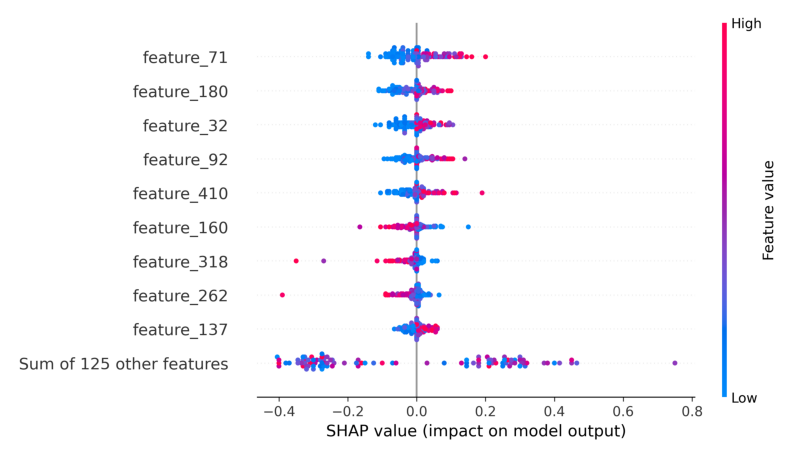

In [15]:
# Number of input features used by the selected model
num_features = X_train_sel.shape[1]

# Minimum number of evaluations required by SHAP
# Rule of thumb: 2 * number_of_features + 1
min_max_evals = 2 * num_features + 1

# Create SHAP explainer with a sufficient number of evaluations
explainer = shap.Explainer(
    best_estimator.predict,
    X_train_sel,
    max_evals=min_max_evals + 100
)

# Explain a subset of the test set to limit computation time
shap_values = explainer(X_test_sel[:100])

# Generate SHAP beeswarm plot
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=10, show=False)

# Save the figure to disk
output_path = "SHAP.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

# Show the figure in the notebook
plt.show()
plt.close()

### **12. Summary and Conclusions**

In this notebook we trained and optimised several classical machine learning classifiers on top of CNN-extracted image features, using stratified cross-validation and ROC AUC as the main selection criterion. Across logistic regression, k-nearest neighbours, support vector machine, decision tree and random forest, the best-performing models reached very high discriminative performance on the internal validation folds.

The hyperparameter-tuned estimators were then evaluated on the held-out internal test set, allowing us to obtain a consistent set of metrics (confusion matrix, sensitivity, specificity, PPV, NPV, F1 score, accuracy and AUC) and to identify the single best hybrid model for subsequent comparison. All trained models and their performance summaries were saved to disk to ensure full reproducibility.

The comparative analysis between this best classical ML model and the end-to-end CNN, including joint ROC plots and statistical comparison of AUCs (e.g. DeLong’s test), is deliberately performed in a dedicated evaluation notebook. This separation keeps the present document focused on the training and optimisation pipeline, while the downstream clinical and statistical interpretation is handled in the corresponding evaluation workflow.
